In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 7.2 MB/s eta 0:00:00


In [ ]:
import glob
import numpy as np
from PIL import Image
from ultralytics import YOLO
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score
import time

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def load_folder(path, label):
    # Adicionado sorted() para garantir que a ordem dos arquivos seja a mesma
    # tanto no dataset original quanto no aumentado
    filelist = sorted(glob.glob(path + "/*.*"))
    X = [np.array(Image.open(fname).resize((256,256))) for fname in filelist]
    X = np.array(X)
    y = np.full((len(X),), label, dtype=np.uint8)
    return X, y


In [ ]:
# TEST
xt_drr, yt_drr = load_folder('/content/drive/MyDrive/Dataset_256_v2/test/Duro', 0)
xt_mole, yt_mole = load_folder('/content/drive/MyDrive/Dataset_256_v2/test/Mole', 1)
xt_q, yt_q = load_folder('/content/drive/MyDrive/Dataset_256_v2/test/RioZona', 2)
xt_rr, yt_rr = load_folder('/content/drive/MyDrive/Dataset_256_v2/test/Riado', 3)
xt_rf, yt_rf = load_folder('/content/drive/MyDrive/Dataset_256_v2/test/Rio', 4)

# TRAIN
xtr_drr, ytr_drr = load_folder('/content/drive/MyDrive/Dataset_256/train/Duro', 0)
xtr_mole, ytr_mole = load_folder('/content/drive/MyDrive/Dataset_256/train/Mole', 1)
xtr_q, ytr_q = load_folder('/content/drive/MyDrive/Dataset_256/train/RioZona', 2)
xtr_rr, ytr_rr = load_folder('/content/drive/MyDrive/Dataset_256/train/Riado', 3)
xtr_rf, ytr_rf = load_folder('/content/drive/MyDrive/Dataset_256/train/Rio', 4)

# VALID
xv_drr, yv_drr = load_folder('/content/drive/MyDrive/Dataset_256/valid/Duro', 0)
xv_mole, yv_mole = load_folder('/content/drive/MyDrive/Dataset_256/valid/Mole', 1)
xv_q, yv_q = load_folder('/content/drive/MyDrive/Dataset_256/valid/RioZona', 2)
xv_rr, yv_rr = load_folder('/content/drive/MyDrive/Dataset_256/valid/Riado', 3)
xv_rf, yv_rf = load_folder('/content/drive/MyDrive/Dataset_256/valid/Rio', 4)

In [ ]:
X_test = np.concatenate([xt_drr, xt_mole, xt_q, xt_rr, xt_rf])
Y_test = np.concatenate([yt_drr, yt_mole, yt_q, yt_rr, yt_rf])

X_orig = np.concatenate([xtr_drr, xtr_mole, xtr_q, xtr_rr, xtr_rf])
Y_orig = np.concatenate([ytr_drr, ytr_mole, ytr_q, ytr_rr, ytr_rf])

X_valid = np.concatenate([xv_drr, xv_mole, xv_q, xv_rr, xv_rf])
Y_valid = np.concatenate([yv_drr, yv_mole, yv_q, yv_rr, yv_rf])

print(X_orig.shape)

(725, 256, 256, 3)


In [ ]:
import os
import shutil
import numpy as np
from PIL import Image

def prepare_yolo_folder(X_train_orig, Y_train_orig, X_train_aug, Y_train_aug,
                        X_val, Y_val, fold):

    base = f"/content/yolo_fold_{fold}"
    run_base = f"{base}_run"

    # Deletar pastas de imagens e de runs antigos para evitar carregar pesos velhos
    if os.path.exists(base):
        shutil.rmtree(base)
    if os.path.exists(run_base):
        shutil.rmtree(run_base)

    os.makedirs(base + "/train")
    os.makedirs(base + "/val")

    # TREINO = originais + aumentadas do SEU dataset (sem vazamento)
    X_train = np.concatenate((X_train_orig, X_train_aug))
    Y_train = np.concatenate((Y_train_orig, Y_train_aug))

    # salvar treino
    for i, (img, label) in enumerate(zip(X_train, Y_train)):
        cls_folder = f"{base}/train/{label}"
        os.makedirs(cls_folder, exist_ok=True)
        Image.fromarray(img).save(f"{cls_folder}/{i}.jpg")

    # salvar validação (somente originais isoladas)
    for i, (img, label) in enumerate(zip(X_val, Y_val)):
        cls_folder = f"{base}/val/{label}"
        os.makedirs(cls_folder, exist_ok=True)
        Image.fromarray(img).save(f"{cls_folder}/{i}.jpg")

    return base


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import time
import numpy as np
from PIL import Image

def evaluate_yolo(model, X, Y):
    preds = []
    start = time.time()

    for img in X:
        # Convert numpy array to PIL Image to avoid BGR/RGB inversion in Ultralytics YOLO
        pil_img = Image.fromarray(img)
        result = model.predict(pil_img, verbose=False)[0]
        preds.append(result.probs.top1)

    end = time.time()
    inference_time = (end - start) / len(X)

    preds = np.array(preds)

    acc = np.mean(preds == Y)
    precision = precision_score(Y, preds, average='macro', zero_division=0)
    recall = recall_score(Y, preds, average='macro', zero_division=0)
    f1 = f1_score(Y, preds, average='macro', zero_division=0)

    return acc, precision, recall, f1, inference_time


In [ ]:
from sklearn.model_selection import KFold
from ultralytics import YOLO
import numpy as np
import os
import shutil
from PIL import Image

def run_kfold_yolo(model_name, X_orig, Y_orig, X_test, Y_test, X_aug=None, Y_aug=None, epochs=50, patience=10, imgsz=256, optimizer='auto', lr0=0.01, weight_decay=0.0005, mixup=0.0, cutmix=0.0, dropout=0.0, label_smoothing=0.0, cos_lr=False):

    k = 5
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    fold = 1

    val_acc_list, val_prec_list, val_rec_list, val_f1_list, val_inf_list = [], [], [], [], []
    test_acc_list, test_prec_list, test_rec_list, test_f1_list, test_inf_list = [], [], [], [], []

    for train_idx, val_idx in kf.split(X_orig):

        print(f"\n========== FOLD {fold} ==========")

        # Separação rigorosa para evitar data leakage
        X_train_orig, X_val = X_orig[train_idx], X_orig[val_idx]
        Y_train_orig, Y_val = Y_orig[train_idx], Y_orig[val_idx]

        # Verifica se estamos usando augmentation externo
        if X_aug is not None and Y_aug is not None:
            X_train_aug = X_aug[train_idx]
            Y_train_aug = Y_aug[train_idx]
        else:
            # Se não houver augmentation externo, usamos arrays vazios para não somar nada extra
            X_train_aug = np.empty((0, *X_orig.shape[1:]), dtype=X_orig.dtype)
            Y_train_aug = np.empty((0,), dtype=Y_orig.dtype)

        fold_path = prepare_yolo_folder(
            X_train_orig, Y_train_orig,
            X_train_aug, Y_train_aug,
            X_val, Y_val,
            fold
        )

        model = YOLO(model_name)

        # Treinamento com os aumentos NATIVOS DO YOLO explicitamente configurados
        model.train(
            data=fold_path,
            epochs=epochs,
            imgsz=imgsz,
            batch=32,
            verbose=False,
            project=f"{fold_path}_run",
            name="train",
            exist_ok=True,
            patience=patience,
            optimizer=optimizer,
            lr0=lr0,
            weight_decay=weight_decay,
            cos_lr=cos_lr,                # Habilita Cosine Annealing Learning Rate
            label_smoothing=label_smoothing, # Habilita Label Smoothing
            dropout=dropout,              # Habilita Dropout na camada de classificação
            augment=True,                 # Enable augmentations
            auto_augment=False,           # Desativamos o randaugment (caixa preta)
            #mixup=mixup,                  # Habilita MixUp
            #cutmix=cutmix,                # Habilita CutMix
            fliplr=0.5,                   # 50% chance espelhamento horizontal
            flipud=0.5,                   # 50% chance espelhamento vertical (seguro para grãos)
            degrees=15.0,                 # Rotações de até 15 graus
            translate=0.1,                # Translação (deslocamento) de até 10%
            scale=0.2,                    # Zoom in / Zoom out de até 20%
            hsv_h=0.0,                    # MANTER 0.0 - Nenhuma alteração de Cor (Hue)
            hsv_s=0.1,                    # Variação mínima na Saturação
            hsv_v=0.2                     # Variação leve no Brilho
        )

        # Load explicitly the best weights from this fold's training
        best_model_path = f"{fold_path}_run/train/weights/best.pt"
        best_model = YOLO(best_model_path)

        # -- Validação --
        v_acc, v_prec, v_rec, v_f1, v_inf = evaluate_yolo(best_model, X_val, Y_val)

        print("\n--- Métricas de Validação ---")
        print(f"Acurácia (Fold {fold}): {v_acc*100:.2f}%")
        print(f"Precision (Fold {fold}): {v_prec*100:.2f}%")
        print(f"Recall (Fold {fold}): {v_rec*100:.2f}%")
        print(f"F1-score (Fold {fold}): {v_f1*100:.2f}%")
        print(f"Inferência média (Fold {fold}): {v_inf*1000:.4f} ms")

        val_acc_list.append(v_acc)
        val_prec_list.append(v_prec)
        val_rec_list.append(v_rec)
        val_f1_list.append(v_f1)
        val_inf_list.append(v_inf)

        # -- Teste --
        t_acc, t_prec, t_rec, t_f1, t_inf = evaluate_yolo(best_model, X_test, Y_test)

        print("\n--- Métricas de Teste ---")
        print(f"Acurácia (Fold {fold}): {t_acc*100:.2f}%")
        print(f"Precision (Fold {fold}): {t_prec*100:.2f}%")
        print(f"Recall (Fold {fold}): {t_rec*100:.2f}%")
        print(f"F1-score (Fold {fold}): {t_f1*100:.2f}%")
        print(f"Inferência média (Fold {fold}): {t_inf*1000:.4f} ms")

        test_acc_list.append(t_acc)
        test_prec_list.append(t_prec)
        test_rec_list.append(t_rec)
        test_f1_list.append(t_f1)
        test_inf_list.append(t_inf)

        fold += 1

    # ============================
    # MÉTRICAS FINAIS DO K-FOLD
    # ============================

    print("\n====================================")
    print(" MÉTRICAS FINAIS DE VALIDAÇÃO (5 FOLDS)")
    print("====================================")
    print(f"Acurácia média: {np.mean(val_acc_list)*100:.2f}% \u00b1 {np.std(val_acc_list)*100:.2f}%")
    print(f"Precision média: {np.mean(val_prec_list)*100:.2f}% \u00b1 {np.std(val_prec_list)*100:.2f}%")
    print(f"Recall média: {np.mean(val_rec_list)*100:.2f}% \u00b1 {np.std(val_rec_list)*100:.2f}%")
    print(f"F1-score média: {np.mean(val_f1_list)*100:.2f}% \u00b1 {np.std(val_f1_list)*100:.2f}%")
    print(f"Tempo médio de inferência: {np.mean(val_inf_list)*1000:.4f} ms \u00b1 {np.std(val_inf_list)*1000:.4f} ms\n")

    print("====================================")
    print(" MÉTRICAS FINAIS DE TESTE (5 FOLDS)")
    print("====================================")
    print(f"Acurácia média: {np.mean(test_acc_list)*100:.2f}% \u00b1 {np.std(test_acc_list)*100:.2f}%")
    print(f"Precision média: {np.mean(test_prec_list)*100:.2f}% \u00b1 {np.std(test_prec_list)*100:.2f}%")
    print(f"Recall média: {np.mean(test_rec_list)*100:.2f}% \u00b1 {np.std(test_rec_list)*100:.2f}%")
    print(f"F1-score média: {np.mean(test_f1_list)*100:.2f}% \u00b1 {np.std(test_f1_list)*100:.2f}%")
    print(f"Tempo médio de inferência: {np.mean(test_inf_list)*1000:.4f} ms \u00b1 {np.std(test_inf_list)*1000:.4f} ms\n")

    return val_acc_list, val_prec_list, val_rec_list, val_f1_list, val_inf_list, test_acc_list, test_prec_list, test_rec_list, test_f1_list, test_inf_list

In [ ]:
run_kfold_yolo(
    model_name="yolo11m-cls.pt", # Arquitetura Medium
    X_orig=X_orig,
    Y_orig=Y_orig,
    X_aug=None,
    Y_aug=None,
    X_test=X_test,
    Y_test=Y_test,
    epochs=50,
    patience=15,
    imgsz=256,
    optimizer='AdamW',
    lr0=0.001,
    weight_decay=0.01,
    mixup=0.3,              # 30% MixUp
    cutmix=0.3,             # 30% CutMix
    dropout=0.2,            # 20% Dropout
    label_smoothing=0.1,    # Label Smoothing de 10%
    cos_lr=True             # Decaimento em Cosseno da LR
)


========== FOLD 1 ==========
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.82 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=False, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/yolo_fold_1, degrees=15.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.2, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.1, hsv_v=0.2, imgsz=256, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tra

([np.float64(1.0),
  np.float64(0.993103448275862),
  np.float64(0.993103448275862),
  np.float64(0.9862068965517241),
  np.float64(0.993103448275862)],
 [1.0, 0.99375, 0.9935483870967742, 0.9876190476190476, 0.993103448275862],
 [1.0,
  0.9925925925925926,
  0.9904761904761905,
  0.9876190476190476,
  0.9947368421052631],
 [1.0,
  0.9930518119197365,
  0.9918432626949221,
  0.9876190476190476,
  0.9938245614035088],
 [0.007761922375909214,
  0.0076352349643049565,
  0.008051495716489594,
  0.007732184179897966,
  0.007758426666259766],
 [np.float64(0.9444444444444444),
  np.float64(0.9555555555555556),
  np.float64(0.9388888888888889),
  np.float64(0.9666666666666667),
  np.float64(0.9277777777777778)],
 [0.9464257964257964,
  0.9553259141494437,
  0.9454181454181454,
  0.9692307692307693,
  0.9318768245597514],
 [0.9444444444444444,
  0.9555555555555555,
  0.9388888888888889,
  0.9666666666666668,
  0.9277777777777777],
 [0.9441256038647342,
  0.9552250489236791,
  0.9368601869971732

In [ ]:
import numpy as np
import glob
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
from collections import Counter
from PIL import Image
from ultralytics import YOLO

# Carregar os modelos treinados em cada fold
list_of_files = sorted(glob.glob('/content/yolo_fold_*_run/train/weights/best.pt'))

if not list_of_files:
    raise FileNotFoundError("Nenhum modelo treinado foi encontrado. Verifique se o treinamento foi concluído com sucesso.")

print("Agrupando imagens de teste em trios por classe...")
triplets_X = []
triplets_Y = []

test_sets = [
    (xt_drr, 0),
    (xt_mole, 1),
    (xt_q, 2),
    (xt_rr, 3),
    (xt_rf, 4)
]

for X_class, label in test_sets:
    for i in range(0, len(X_class) - 2, 3):
        triplets_X.append([X_class[i], X_class[i+1], X_class[i+2]])
        triplets_Y.append(label)

print(f"Total de trios formados para avaliação: {len(triplets_X)}\n")

X_test_flat = np.concatenate((xt_drr, xt_mole, xt_q, xt_rr, xt_rf), axis=0)
Y_test_flat = np.concatenate((yt_drr, yt_mole, yt_q, yt_rr, yt_rf), axis=0)

# Dicionários para acumular as métricas dos 5 folds
metrics_history = {
    "INDIVIDUAL (PADRÃO)": {"acc": [], "prec": [], "rec": [], "f1": []},
    "ENSEMBLE POR MODA": {"acc": [], "prec": [], "rec": [], "f1": []},
    "ENSEMBLE POR MÉDIA DE CONFIANÇA": {"acc": [], "prec": [], "rec": [], "f1": []},
    "ENSEMBLE POR MAIS ALTA CONFIANÇA": {"acc": [], "prec": [], "rec": [], "f1": []}
}

def calc_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return acc, prec, rec, f1

# Loop sobre todos os modelos dos folds
for fold_idx, model_path in enumerate(list_of_files, 1):
    print(f"Avaliando Modelo {fold_idx}/5: {model_path}...")

    model = YOLO(model_path)

    # --- 1. MÉTODOS INDIVIDUAIS (PADRÃO) PARA COMPARAÇÃO ---
    preds_flat_test = []

    for img in X_test_flat:
        pil_img = Image.fromarray(img)
        res = model.predict(pil_img, verbose=False)
        preds_flat_test.append(np.argmax(res[0].probs.data.cpu().numpy()))

    acc, prec, rec, f1 = calc_metrics(Y_test_flat, preds_flat_test)
    metrics_history["INDIVIDUAL (PADRÃO)"]["acc"].append(acc)
    metrics_history["INDIVIDUAL (PADRÃO)"]["prec"].append(prec)
    metrics_history["INDIVIDUAL (PADRÃO)"]["rec"].append(rec)
    metrics_history["INDIVIDUAL (PADRÃO)"]["f1"].append(f1)

    # --- 2. ENSEMBLE DE TRIOS ---
    preds_mode = []
    preds_mean = []
    preds_highest = []

    for triplet in triplets_X:
        probs_list = []
        class_preds = []
        max_confs = []

        for img in triplet:
            pil_img = Image.fromarray(img)
            res = model.predict(pil_img, verbose=False)
            if res and res[0].probs is not None:
                probs = res[0].probs.data.cpu().numpy()
                probs_list.append(probs)
                class_preds.append(np.argmax(probs))
                max_confs.append(np.max(probs))

        if len(probs_list) == 3:
            # Ensemble por Moda
            moda = Counter(class_preds).most_common(1)[0][0]
            preds_mode.append(moda)

            # Ensemble por Média das Confianças
            mean_probs = np.mean(probs_list, axis=0)
            preds_mean.append(np.argmax(mean_probs))

            # Ensemble por Mais Alta Confiança (Max Prob)
            best_idx = np.argmax(max_confs)
            preds_highest.append(class_preds[best_idx])
        else:
            preds_mode.append(-1)
            preds_mean.append(-1)
            preds_highest.append(-1)

    # Filtrar falhas
    valid_indices = [i for i, p in enumerate(preds_mode) if p != -1]
    Y_true = np.array(triplets_Y)[valid_indices]
    preds_mode_arr = np.array(preds_mode)[valid_indices]
    preds_mean_arr = np.array(preds_mean)[valid_indices]
    preds_highest_arr = np.array(preds_highest)[valid_indices]

    # Coletar métricas do Ensemble
    acc, prec, rec, f1 = calc_metrics(Y_true, preds_mode_arr)
    metrics_history["ENSEMBLE POR MODA"]["acc"].append(acc)
    metrics_history["ENSEMBLE POR MODA"]["prec"].append(prec)
    metrics_history["ENSEMBLE POR MODA"]["rec"].append(rec)
    metrics_history["ENSEMBLE POR MODA"]["f1"].append(f1)

    acc, prec, rec, f1 = calc_metrics(Y_true, preds_mean_arr)
    metrics_history["ENSEMBLE POR MÉDIA DE CONFIANÇA"]["acc"].append(acc)
    metrics_history["ENSEMBLE POR MÉDIA DE CONFIANÇA"]["prec"].append(prec)
    metrics_history["ENSEMBLE POR MÉDIA DE CONFIANÇA"]["rec"].append(rec)
    metrics_history["ENSEMBLE POR MÉDIA DE CONFIANÇA"]["f1"].append(f1)

    acc, prec, rec, f1 = calc_metrics(Y_true, preds_highest_arr)
    metrics_history["ENSEMBLE POR MAIS ALTA CONFIANÇA"]["acc"].append(acc)
    metrics_history["ENSEMBLE POR MAIS ALTA CONFIANÇA"]["prec"].append(prec)
    metrics_history["ENSEMBLE POR MAIS ALTA CONFIANÇA"]["rec"].append(rec)
    metrics_history["ENSEMBLE POR MAIS ALTA CONFIANÇA"]["f1"].append(f1)

print("\n======================================================")
print("       MÉTRICAS FINAIS CONSOLIDADAS (5 MODELOS) ")
print("======================================================")

for method_name, metrics in metrics_history.items():
    print(f"\n>>> {method_name} <<<")
    print(f"Acurácia Média:  {np.mean(metrics['acc'])*100:.2f}% ± {np.std(metrics['acc'])*100:.2f}%")
    print(f"Precision Média: {np.mean(metrics['prec'])*100:.2f}% ± {np.std(metrics['prec'])*100:.2f}%")
    print(f"Recall Médio:    {np.mean(metrics['rec'])*100:.2f}% ± {np.std(metrics['rec'])*100:.2f}%")
    print(f"F1-Score Médio:  {np.mean(metrics['f1'])*100:.2f}% ± {np.std(metrics['f1'])*100:.2f}%")


Agrupando imagens de teste em trios por classe...
Total de trios formados para avaliação: 60

Avaliando Modelo 1/5: /content/yolo_fold_1_run/train/weights/best.pt...
Avaliando Modelo 2/5: /content/yolo_fold_2_run/train/weights/best.pt...
Avaliando Modelo 3/5: /content/yolo_fold_3_run/train/weights/best.pt...
Avaliando Modelo 4/5: /content/yolo_fold_4_run/train/weights/best.pt...
Avaliando Modelo 5/5: /content/yolo_fold_5_run/train/weights/best.pt...

       MÉTRICAS FINAIS CONSOLIDADAS (5 MODELOS) 

>>> INDIVIDUAL (PADRÃO) <<<
Acurácia Média:  94.67% ± 1.34%
Precision Média: 94.97% ± 1.23%
Recall Médio:    94.67% ± 1.34%
F1-Score Médio:  94.61% ± 1.32%

>>> ENSEMBLE POR MODA <<<
Acurácia Média:  96.33% ± 1.94%
Precision Média: 96.73% ± 1.62%
Recall Médio:    96.33% ± 1.94%
F1-Score Médio:  96.24% ± 2.05%

>>> ENSEMBLE POR MÉDIA DE CONFIANÇA <<<
Acurácia Média:  96.67% ± 2.11%
Precision Média: 97.14% ± 1.62%
Recall Médio:    96.67% ± 2.11%
F1-Score Médio:  96.62% ± 2.17%

>>> ENSEMBLE P

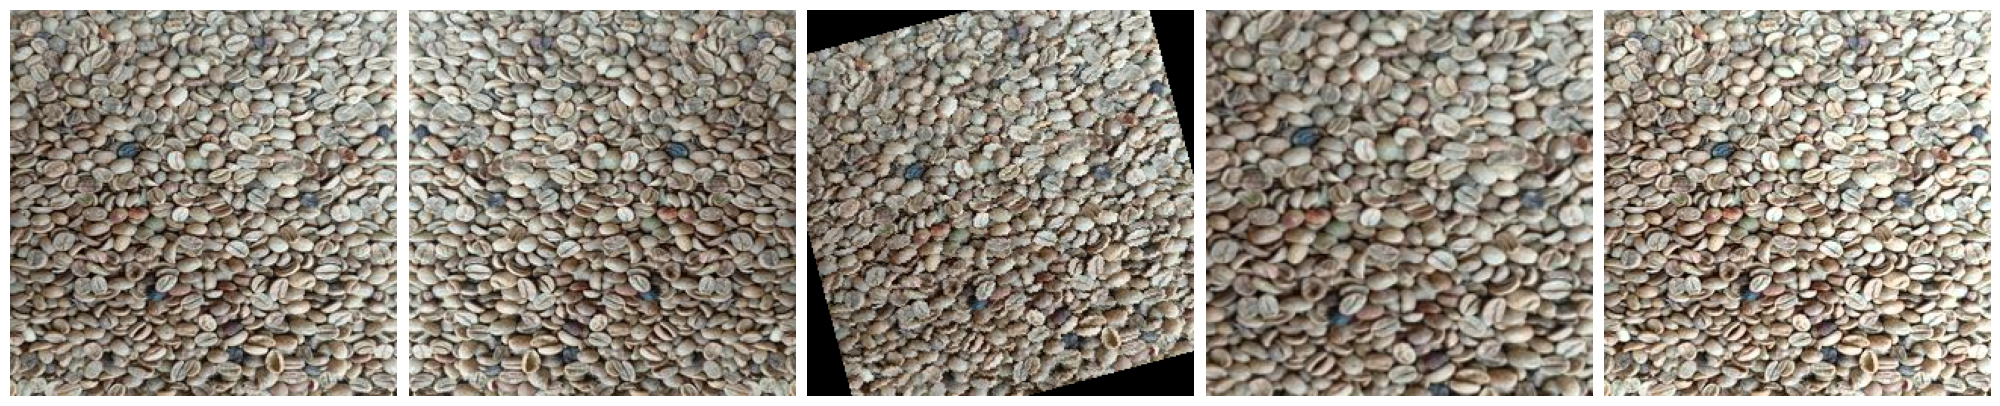

Imagem salva com sucesso com espaçamento ajustado!


In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from PIL import Image

# Recriando as imagens com as transformações
img_orig = X_orig[0]
img_flip = np.fliplr(img_orig)
img_rot = np.array(Image.fromarray(img_orig).rotate(15))

h, w = img_orig.shape[:2]
crop_h, crop_w = int(h * 0.8), int(w * 0.8)
y1, x1 = (h - crop_h) // 2, (w - crop_w) // 2
img_crop = img_orig[y1:y1+crop_h, x1:x1+crop_w]
img_zoom = cv2.resize(img_crop, (w, h))

hsv = cv2.cvtColor(img_orig, cv2.COLOR_RGB2HSV).astype(np.float32)
hsv[:, :, 2] = np.clip(hsv[:, :, 2] * 1.2, 0, 255)
img_value = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

# Plotando as imagens sem nenhum texto/legenda
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

images = [img_orig, img_flip, img_rot, img_zoom, img_value]

for ax, img in zip(axes, images):
    ax.imshow(img)
    ax.axis("off")  # Remove os eixos

# Ajusta o layout para manter um pequeno espaço entre as imagens
plt.subplots_adjust(wspace=0.1, hspace=0)
plt.tight_layout(pad=0.5)

# Salva a figura em formato PNG
plt.savefig('augmentations.png', format='png', bbox_inches='tight', pad_inches=0.1)
plt.show()

print("Imagem salva com sucesso com espaçamento ajustado!")